In [2]:
from chemdiagrams import EnergyDiagram

# Dummy data
x_data_1 = [0,1,2,3,4,5]
x_data_2 = [0,1,2,3,5]
x_data_3 = [0,1,2,3,4]

y_data_1 = [0,-13,22,75,39,-25]
y_data_2 = [0,-25,20,60,45,6]
y_data_3 = [0,-15,20,55,5]
y_data_4 = [-16, 38, 0, 44, -22]

# Minimal use example

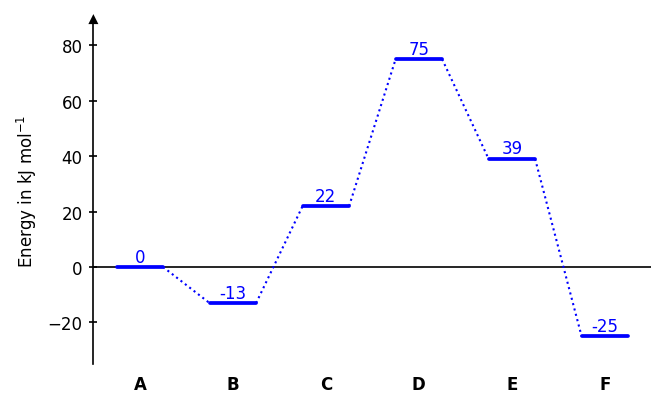

In [2]:
dia1 = EnergyDiagram()

dia1.draw_path(
    x_data=x_data_1,
    y_data=y_data_1,
    color='blue',
)

dia1.add_numbers_auto()

dia1.set_xlabels(["A", "B", "C", "D", "E", "F"])

dia1.ax.set_ylabel("Energy in kJ mol$^{-1}$", fontsize=8)

dia1.show()

# General settings

Currently figures have a fixed height of 3 inches and scale vertical automatically. The maximum figure width via automatic scaling is 7 inches, since more is too large for a standard A4 document.

The automatic figure scaling can be overwritten by manual inputs though. 

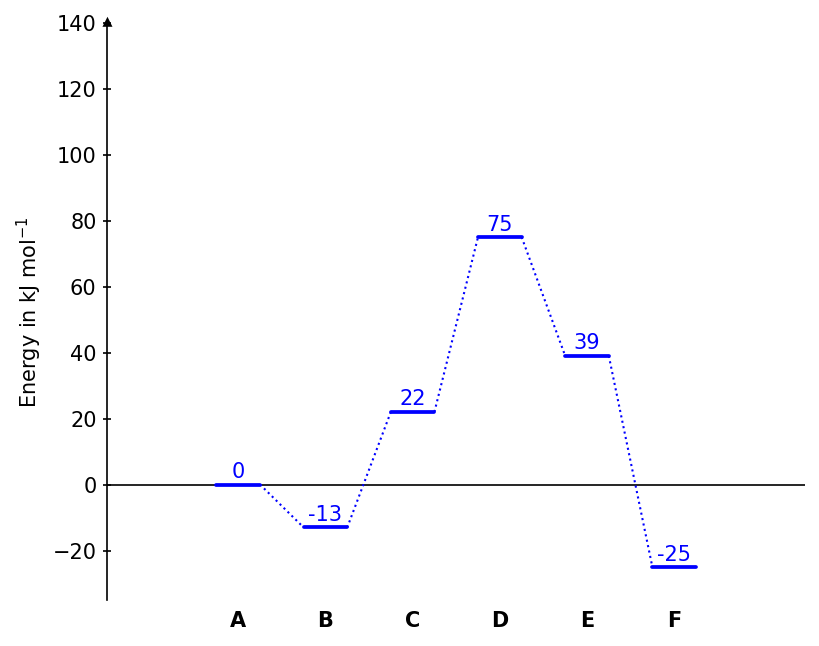

In [3]:
dia1 = EnergyDiagram(
    extra_x_margin=(-1,1),      # Extra margin in x directions (in axis units)
    extra_y_margin=(0,0.5),     # Extra margin in y directions (in relative units)
    fontsize=10,                
    figsize=(6,5),              # Manual determination of figure size
    width_limit=7,              # Sets the maximum width of the diagram to 7 inches
)

dia1.draw_path(
    x_data=x_data_1,
    y_data=y_data_1,
    color='blue',
)

dia1.add_numbers_auto()

dia1.set_xlabels(["A", "B", "C", "D", "E", "F"])
dia1.ax.set_ylabel("Energy in kJ mol$^{-1}$", fontsize=10)
dia1.show()

# Connector line types

Five different connector line types exist, which can be specified via linetypes:
- 1: dotted line (default)
- -1: dotted line with gap
- 2: solid line
- -2: solid line with gap
- 0: no line
- 3: dotted cubic spline
- 4: solid cubic spline

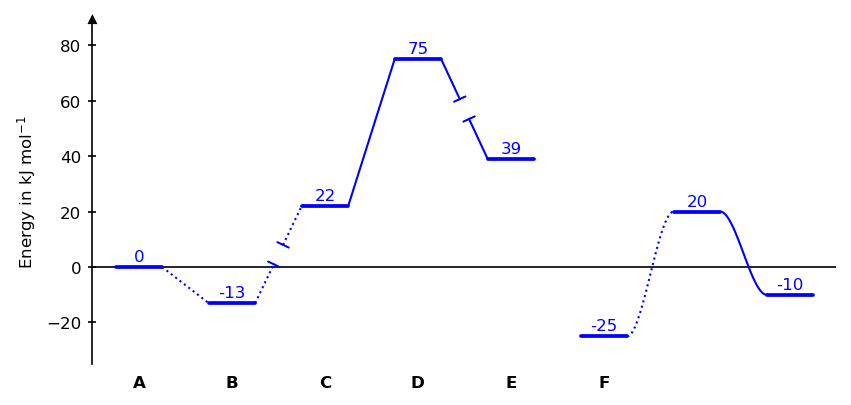

In [3]:
dia1 = EnergyDiagram()

dia1.draw_path(
    x_data=x_data_1 + [6, 7],
    y_data=y_data_1 + [20, -10],
    color='blue',
    linetypes=[1,-1,2,-2,0,3,4],
)

dia1.add_numbers_auto()

dia1.set_xlabels(["A", "B", "C", "D", "E", "F"])
dia1.ax.set_ylabel("Energy in kJ mol$^{-1}$", fontsize=8)
dia1.show()

Giving an integer for linetypes changes all connectors of that path to that style.

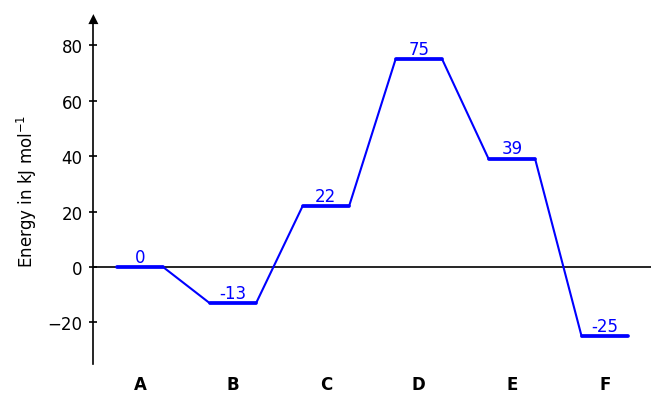

In [5]:
dia1 = EnergyDiagram()

dia1.draw_path(
    x_data=x_data_1,
    y_data=y_data_1,
    color='blue',
    linetypes=2,
)

dia1.add_numbers_auto()

dia1.set_xlabels(["A", "B", "C", "D", "E", "F"])
dia1.ax.set_ylabel("Energy in kJ mol$^{-1}$", fontsize=8)
dia1.show()

The plateau widths can be adjusted via width_plateau (in data units) and the line widths of the plateaus can be adjusted via lw_plateau. The latter can be a float in points, or a string referring to a predefined value ("plateau" or "connector").

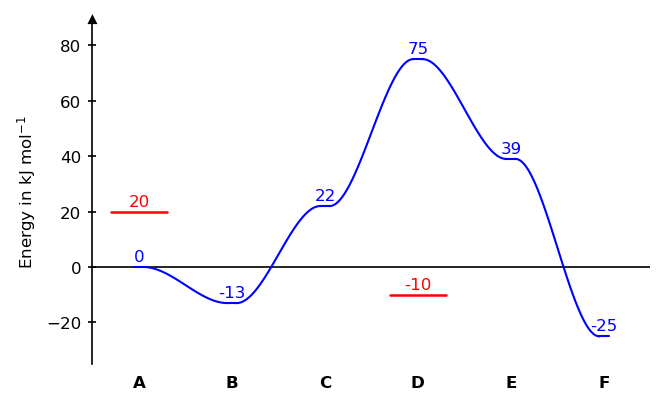

In [13]:
dia1 = EnergyDiagram()

dia1.draw_path(
    x_data=x_data_1,
    y_data=y_data_1,
    color='blue',
    linetypes=4,
    width_plateau=0.1,
    lw_plateau="connector",
)

dia1.draw_path(
    x_data=[0,3],
    y_data=[20, -10],
    color='red',
    linetypes=0,
    width_plateau=0.6,
    lw_plateau=1.2,
)

dia1.add_numbers_auto()

dia1.set_xlabels(["A", "B", "C", "D", "E", "F"])
dia1.ax.set_ylabel("Energy in kJ mol$^{-1}$", fontsize=8)
dia1.show()

# Multiple paths and numbering

There are different methods for numbering the reaction paths. 
- add_numbers_naive(): This adds the numbers directly above the respective plateu.
- add_numbers_stacked(): This stacks the numbers above the highest plateau.
- add_numbers_auto(): This distributes the numbers automatically, so no overlaps occur.
- add_numbers_average(): This just displays the average of all values the respective x.

Numbering should take place after all the paths have been drawn. Else scaling issues may occur.

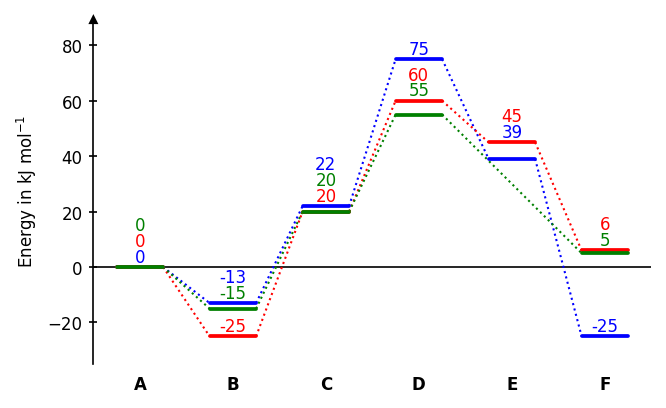

In [6]:
dia1 = EnergyDiagram()

dia1.draw_path(
    x_data=x_data_1,
    y_data=y_data_1,
    color='blue',
)

dia1.draw_path(
    x_data=x_data_1,
    y_data=y_data_2,
    color='red',
)

dia1.draw_path(
    x_data=x_data_2,
    y_data=y_data_3,
    color='green',
)

dia1.add_numbers_auto()

dia1.set_xlabels(["A", "B", "C", "D", "E", "F"])
dia1.ax.set_ylabel("Energy in kJ mol$^{-1}$", fontsize=8)
dia1.show()

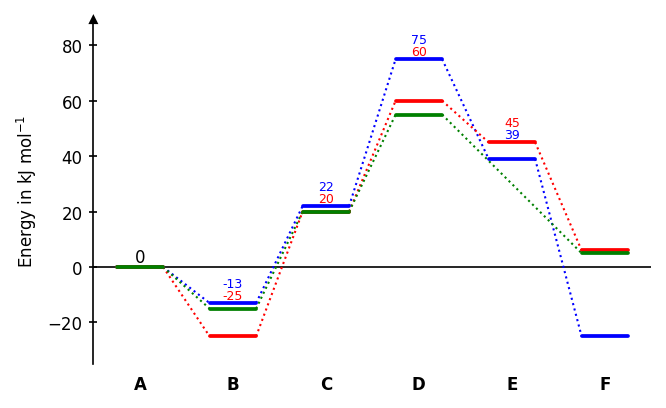

In [7]:
dia1 = EnergyDiagram()

dia1.draw_path(
    x_data=x_data_1,
    y_data=y_data_1,
    color='blue',
)

dia1.draw_path(
    x_data=x_data_1,
    y_data=y_data_2,
    color='red',
)

dia1.draw_path(
    x_data=x_data_2,
    y_data=y_data_3,
    color='green',
    show_numbers=False      # Numbering can also be turned of for each path
)


dia1.add_numbers_stacked(
    x_min_max=(1,4),        # x_min_max (inclusive) can be used to adjust the range, where the numbers are to be plotted
    fontsize=6,             # scale the size of the numbers
)

dia1.add_numbers_average(
    x_min_max=0,            # x_min_max also accepts integers
    color="black"
)

dia1.set_xlabels(["A", "B", "C", "D", "E", "F"])
dia1.ax.set_ylabel("Energy in kJ mol$^{-1}$", fontsize=8)
dia1.show()

If the paths are given names, they are automatically included in the legend. Naming should take place if there is manual tweaking of the matplotlib objects later.

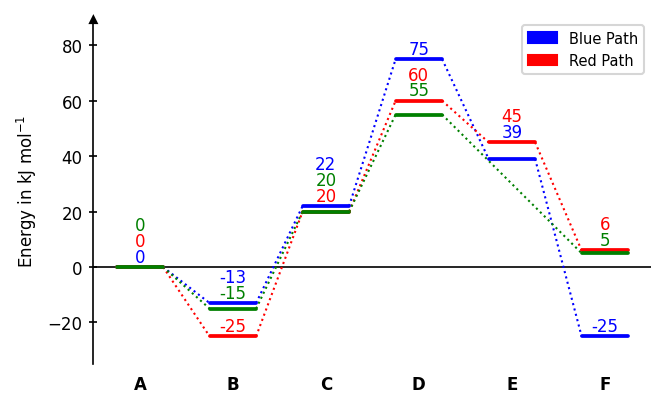

In [8]:
dia1 = EnergyDiagram()

dia1.draw_path(
    x_data=x_data_1,
    y_data=y_data_1,
    path_name="Blue Path",
    color='blue',
)

dia1.draw_path(
    x_data=x_data_1,
    y_data=y_data_2,
    path_name="Red Path",
    color='red',
)

dia1.draw_path(
    x_data=x_data_2,
    y_data=y_data_3,
    color='green',
)


dia1.legend(fontsize=7)                     # Only named paths get displayed

dia1.add_numbers_auto()
dia1.set_xlabels(["A", "B", "C", "D", "E", "F"])
dia1.ax.set_ylabel("Energy in kJ mol$^{-1}$", fontsize=8)
dia1.show()

It is possible to merge two plateaus if they share the same x and y position

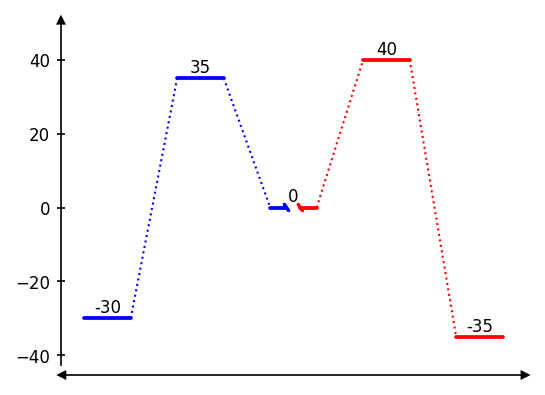

In [9]:
dia = EnergyDiagram(style="twosided")

dia.draw_path(
    [0,1,2], [-30,35,0], "blue",
    path_name="Blue path",
    linetypes=[1,1],
)

dia.draw_path(
    [2,3,4], [0, 40, -35], "red",
    path_name="Red path",
    linetypes=[1,1],
)

dia.merge_plateaus(
    2, 
    "Blue path",            # Path on the left
    "Red path",             # Path on the right
    gap_scale=1.5,          # Scaling of the gap
    stopper_scale=1.2,      # Scaling of the stoppers
    angle=35                # Angle of the stoppers to the vertical
)

dia.add_numbers_average(color="black")
dia.show()

# Diagram style

## Main style option

There are four styles which can be chosen from:
- open (default)
- halfboxed
- boxed
- twosided
- borderless

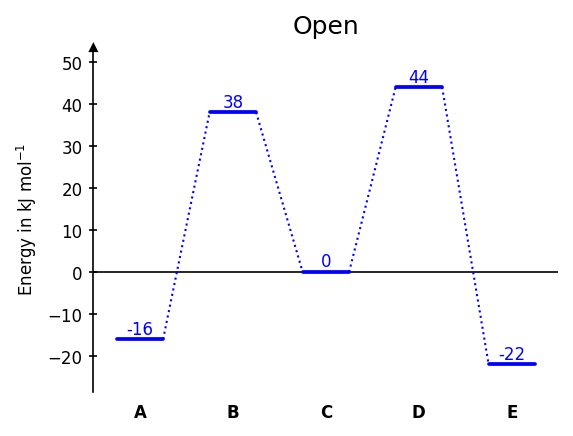

In [10]:
dia1 = EnergyDiagram(style="open")      # Style can be specified here

dia1.draw_path(
    x_data=x_data_3,
    y_data=y_data_4,
    color='blue',
)

dia1.add_numbers_auto()
dia1.set_xlabels(["A", "B", "C", "D", "E"])
dia1.ax.set_ylabel("Energy in kJ mol$^{-1}$", fontsize=8)

dia1.set_diagram_style("open")          # Style can also be specified here

dia1.ax.set_title("Open")
dia1.show()

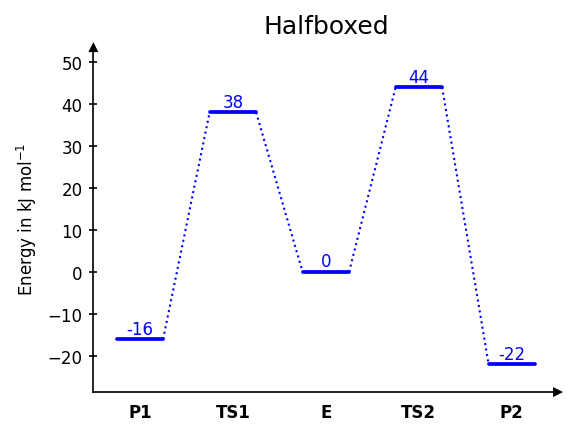

In [11]:
dia1 = EnergyDiagram()

dia1.draw_path(
    x_data=x_data_3,
    y_data=y_data_4,
    color='blue',
)


dia1.add_numbers_auto()
dia1.set_xlabels(["P1", "TS1", "E", "TS2", "P2"])
dia1.ax.set_ylabel("Energy in kJ mol$^{-1}$", fontsize=8)

dia1.set_diagram_style("halfboxed")
dia1.ax.set_title("Halfboxed")
dia1.show()

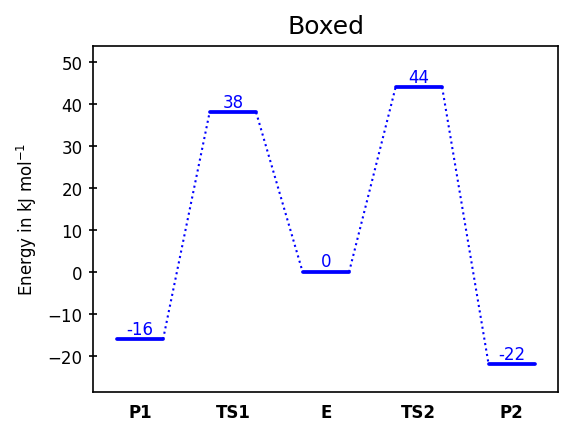

In [12]:
dia1 = EnergyDiagram()

dia1.draw_path(
    x_data=x_data_3,
    y_data=y_data_4,
    color='blue',
)


dia1.add_numbers_auto()
dia1.set_xlabels(["P1", "TS1", "E", "TS2", "P2"])
dia1.ax.set_ylabel("Energy in kJ mol$^{-1}$", fontsize=8)

dia1.set_diagram_style("boxed")
dia1.ax.set_title("Boxed")
dia1.show()

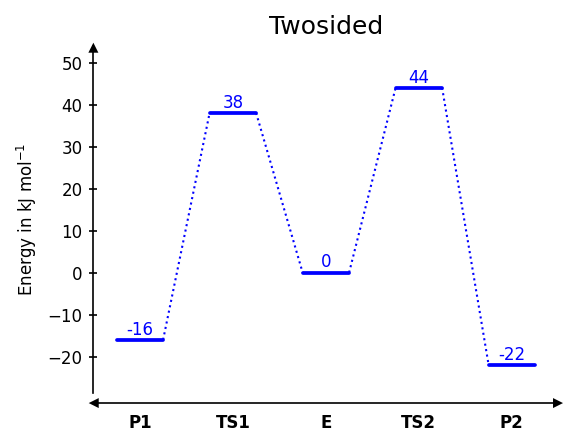

In [13]:
dia1 = EnergyDiagram()

dia1.draw_path(
    x_data=x_data_3,
    y_data=y_data_4,
    color='blue',
)


dia1.add_numbers_auto()
dia1.set_xlabels(["P1", "TS1", "E", "TS2", "P2"])
dia1.ax.set_ylabel("Energy in kJ mol$^{-1}$", fontsize=8)

dia1.set_diagram_style("twosided")
dia1.ax.set_title("Twosided")
dia1.show()

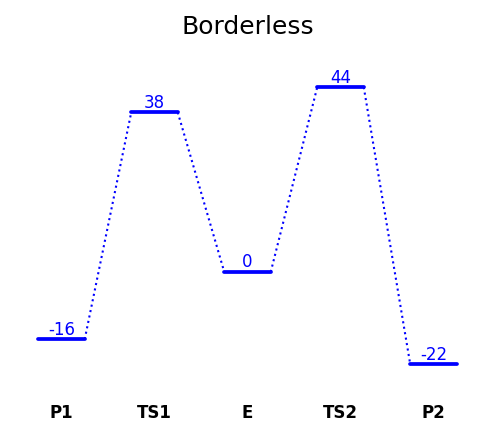

In [14]:
dia1 = EnergyDiagram()

dia1.draw_path(
    x_data=x_data_3,
    y_data=y_data_4,
    color='blue',
)


dia1.add_numbers_auto()
dia1.set_xlabels(["P1", "TS1", "E", "TS2", "P2"], fontsize=8)
#dia1.ax.set_ylabel("Energy in kJ mol$^{-1}$", fontsize=8)

dia1.set_diagram_style("borderless")
dia1.ax.set_title("Borderless")
dia1.show()

## Axes breaks

It is possible to add small breaks to the x and y axis. However, for style="open" it is not possible to draw an x axis break.

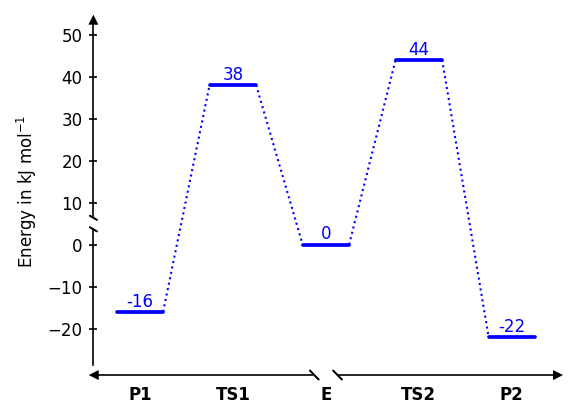

In [15]:
dia1 = EnergyDiagram(style="twosided")

dia1.draw_path(
    x_data=x_data_3,
    y_data=y_data_4,
    color='blue',
)


dia1.add_yaxis_break(5)

dia1.add_xaxis_break(
    2,                      # x position
    gap_scale=2,            # scale the gap
    stopper_scale=1.5,      # scale the stopper size
    angle=60                # angle of the stoppers (0 is perpendicular to axis)
)

dia1.add_numbers_auto()
dia1.set_xlabels(["P1", "TS1", "E", "TS2", "P2"])
dia1.ax.set_ylabel("Energy in kJ mol$^{-1}$", fontsize=8)
dia1.show()

# Labeling

## x-axis labels

x labels can be shown in the graph underneath the plateus using in_plot=True.

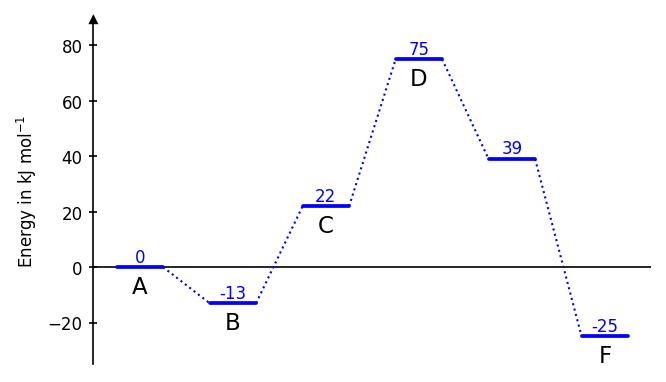

In [16]:
dia1 = EnergyDiagram()

dia1.draw_path(
    x_data=x_data_1,
    y_data=y_data_1,
    color='blue',
)

dia1.add_numbers_auto()

dia1.set_xlabels(
    ["A", "B", "C", "D", "F"], 
    labelplaces=[0,1,2,3,5], # Manual plaxing of labels
    weight="normal", # Adjustment of fontweight
    fontsize=11, # Adjustment of fontsize
    in_plot=True # Displaying the labels directly in the plot
    )

dia1.ax.set_ylabel("Energy in kJ mol$^{-1}$", fontsize=8)

dia1.show()

## Path labels

Path labels can be added to the graph using add_path_labels(). The labels are placed below the respective paths, similar to set_xlabels(..., in_plot=True). However the path labels are places below the plateau of the respective path, while the x labels are placed below the lowest plateau. Furthermore path labels allow for coloring.

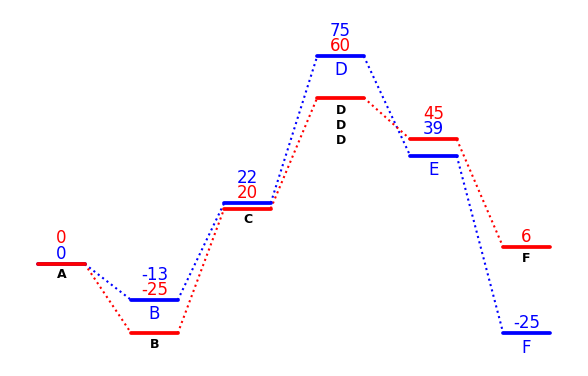

In [ ]:
dia1 = EnergyDiagram(style="borderless")

dia1.draw_path(
    x_data=x_data_1,
    y_data=y_data_1,
    color='blue',
    path_name="Blue path"
)

dia1.draw_path(
    x_data=x_data_1,
    y_data=y_data_2,
    color='red',
    path_name="Red path"
)

dia1.add_path_labels(
    "Blue path",                        # Name of the path, for which the labels are to be added
    [None, "B", None, "D", "E", "F"]    # Labels for the path, None can be used to not display a label at a specific position
)

dia1.add_path_labels(
    "Red path",
    ["A", "B", "C", "D\nD\nD", None, "F"],
    fontsize=6,
    color="black",
    weight="bold"
)

dia1.add_numbers_auto()
dia1.show()

# Difference Bars

There is the possiblity for plotting difference bars with automatic calculation of the numeric difference. In case the difference bars are not fully displayed in the diagram, the boundaries have to be adjusted manually.

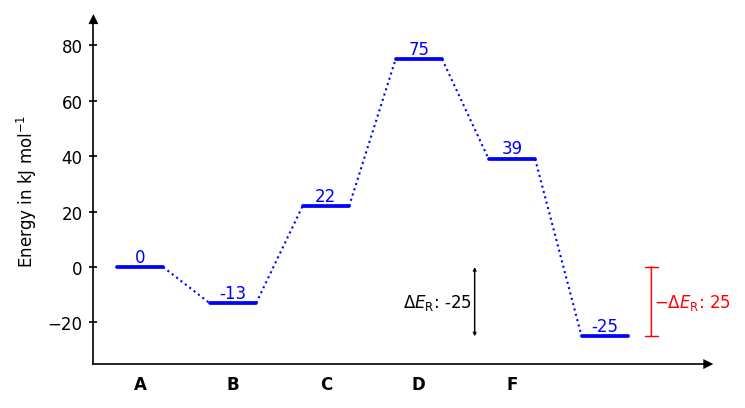

In [17]:
dia1 = EnergyDiagram(
    style="halfboxed",
    extra_x_margin=(0,0.6)
    )

dia1.draw_path(
    x_data=x_data_1,
    y_data=y_data_1,
    color='blue',
)

dia1.draw_difference_bar(
    5.5,                            # x location
    (y_data_1[5], y_data_1[0]),     # (y_start, y_end)
    r"$-\Delta E_\mathrm{R}$: ",    # description
    color="red",                    
)

dia1.draw_difference_bar(
    3.6,                            
    (y_data_1[0], y_data_1[5]),     
    r"$\Delta E_\mathrm{R}$: ",     
    arrowstyle="<->",               # arrowstyle accepts all matplotlib styles
    left_side=True,                 # put text to left side
)

dia1.add_numbers_auto()

dia1.set_xlabels(["A", "B", "C", "D", "F"])
dia1.ax.set_ylabel("Energy in kJ mol$^{-1}$", fontsize=8)
dia1.show()

It is possible to add ''whiskers'' to the difference bar.

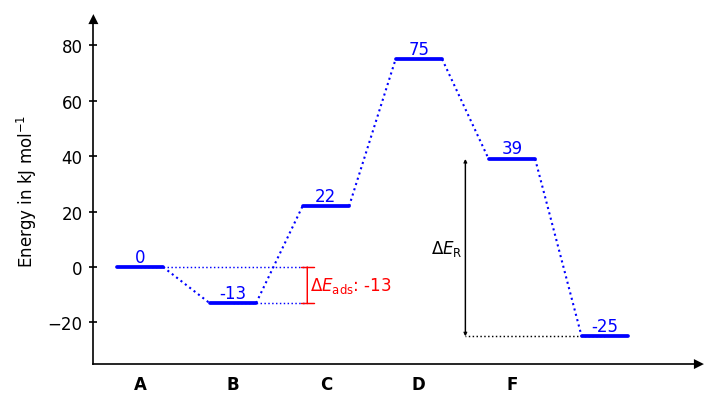

In [18]:
dia1 = EnergyDiagram(
    style="halfboxed",
    extra_x_margin=(0,0.5)
)

dia1.draw_path(
    x_data=x_data_1,
    y_data=y_data_1,
    color='blue',
)

dia1.draw_difference_bar(
    1.8,                            
    (y_data_1[0], y_data_1[1]),     
    r"$\Delta E_\mathrm{ads}$: ",
    color="red",   
    x_whiskers=(0,1),               # x positions (start, end) to which the whiskers connect
    whiskercolor="blue"             # Whiskers can take separate color
)

dia1.draw_difference_bar(
    3.5,                            
    (y_data_1[5], y_data_1[4]),     
    r"$\Delta E_\mathrm{R}$",     
    arrowstyle="<->",     
    left_side=True,
    x_whiskers=(5, None),          # x positions can take none as an argument to not draw a whisker
    add_difference=False          # Automatic calculation of the difference can be turned off
)

dia1.add_numbers_auto()

dia1.set_xlabels(["A", "B", "C", "D", "F"])
dia1.ax.set_ylabel("Energy in kJ mol$^{-1}$", fontsize=8)
dia1.show()

# Adding Images

There is the possibility for adding (e.g. png or jpeg, svg and eps are not supported) to the EnergyDiagram. There are two methods for that:
- add_image_in_plot(): Adding a single image at a specified position.
- add_image_series_in_plot(): Adding a series of images along the plot with automatic distribution along y.

As for the numbering methods, it is strongly recommended here, to use the image methods after all the paths were drawn. When inserting images, it is also recommended to increase the dpi manually. As with difference bars, the figure axis limits do not automatically adjust for figures, so manual use of extra_y_margin/extra_x_margin can be neccesarry.

In [19]:
# Get dummy images
import os
penguin = os.path.join("figures", "penguin.png")
penguin_TS = os.path.join("figures", "penguin_TS.png")
penguin_II = os.path.join("figures", "penguin_2.png")

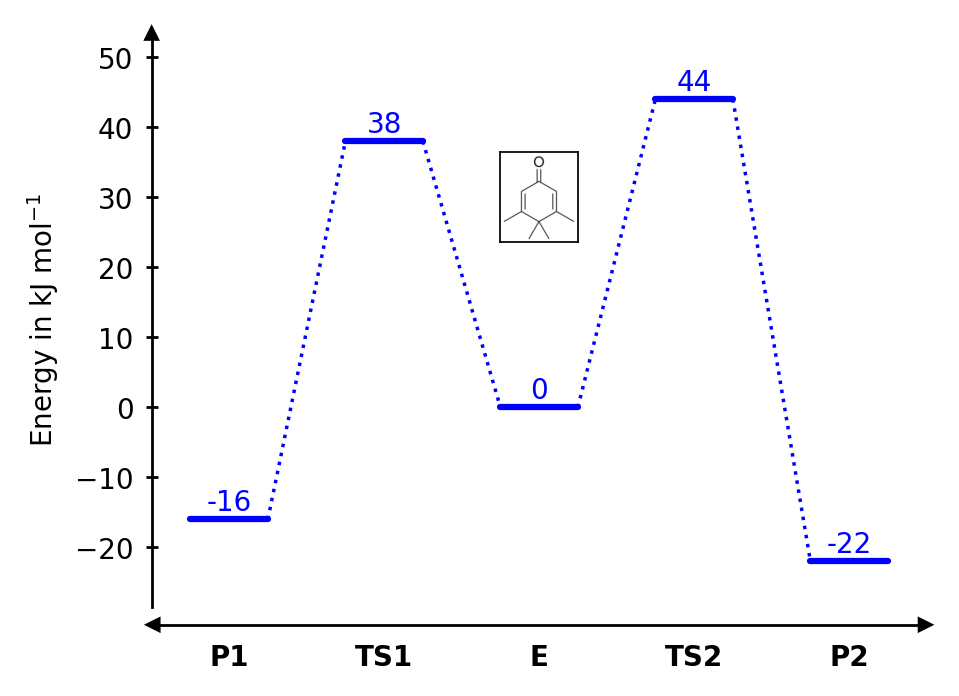

In [20]:
dia1 = EnergyDiagram(
    dpi=250,
    style="twosided"
)

dia1.draw_path(
    x_data=x_data_3,
    y_data=y_data_4,
    color='blue',
)

dia1.add_numbers_auto()
dia1.set_xlabels(["P1", "TS1", "E", "TS2", "P2"])
dia1.ax.set_ylabel("Energy in kJ mol$^{-1}$", fontsize=8)

dia1.add_image_in_plot(
    penguin,
    (2, 30),
    img_name="Penguin",                 # name of the image for storage, useful if the mpl objects are accessed later
    horizontal_alignment="center",      # left, right or center
    vertical_alignment="center",        # top, bottom or center
    width=0.5,                          # width in axis units
    #height=20                          # height can be also specifies in axis units, if only one of width and height is specified, the aspect ratio is preserved
    framed=True,                        # build frame around image
    frame_color="black",                 # set color of the frame
)

dia1.show()

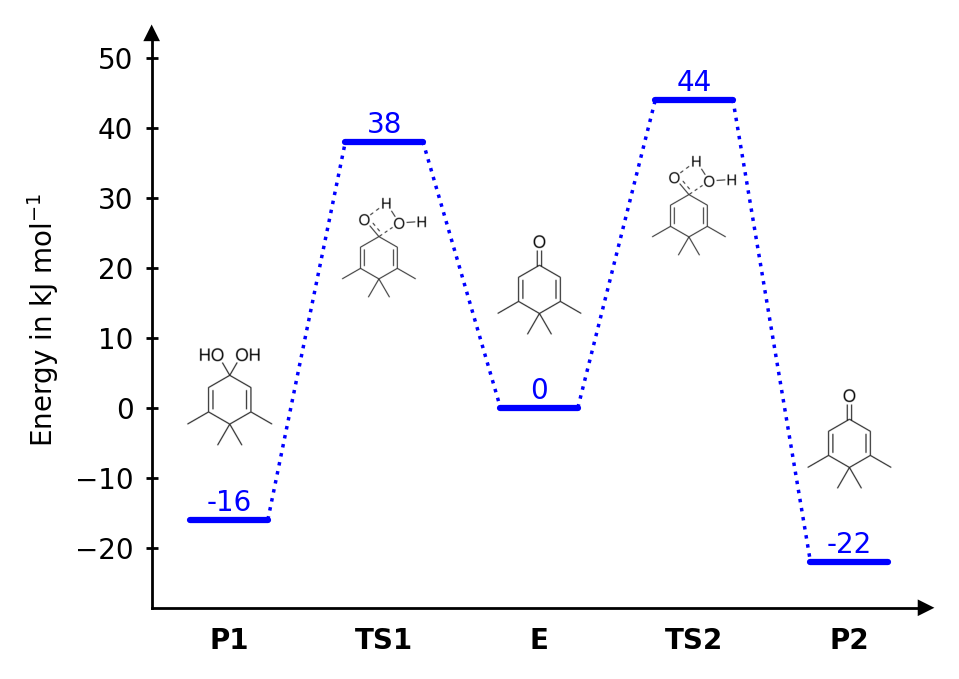

In [21]:
dia1 = EnergyDiagram(
    dpi=250,
    style="halfboxed"
)

dia1.draw_path(
    x_data=x_data_3,
    y_data=y_data_4,
    color='blue',
)

dia1.add_numbers_auto()
dia1.set_xlabels(["P1", "TS1", "E", "TS2", "P2"])
dia1.ax.set_ylabel("Energy in kJ mol$^{-1}$", fontsize=8)

dia1.add_image_series_in_plot(
    [penguin_II, penguin_TS, penguin, penguin_TS, penguin],
    y_offsets=5                                                # increase space between images plateaus objects                         
)

dia1.show()

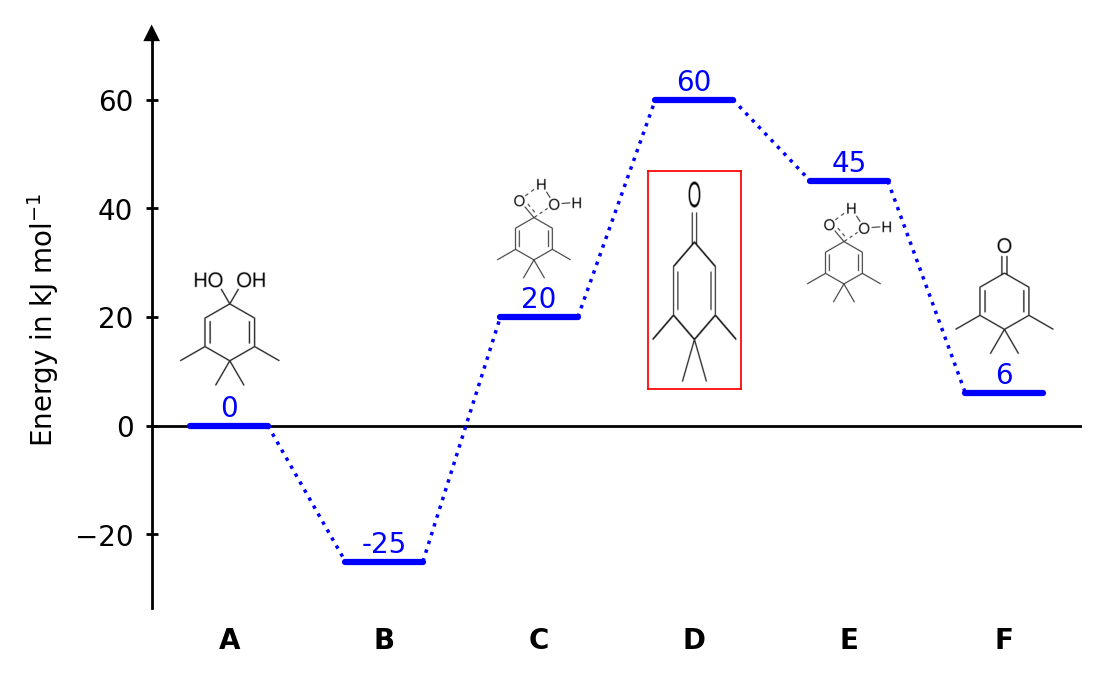

In [22]:
dia1 = EnergyDiagram(
    dpi=250,
)

dia1.draw_path(
    x_data=x_data_1,
    y_data=y_data_2,
    color='blue',
)

dia1.add_numbers_auto()
dia1.set_xlabels(["A", "B", "C", "D", "E", "F"])
dia1.ax.set_ylabel("Energy in kJ mol$^{-1}$", fontsize=8)

dia1.add_image_series_in_plot(
    [penguin_II, penguin_TS, penguin, penguin_TS, penguin],
    img_x_places=[0,2,3,4,5],                                   # x places of the images
    y_placement=["auto","top","auto","bottom","auto"],          # wheter to put the image on top or bottom of the path objects or to decide automatically
    y_offsets=[0, 0, 10, 0, 0],                                 # offset of each image, for images placed below, a higher offset decreases the y coordinate
    img_series_name="Penguin Series",                           # name of the image series for storage, useful if the mpl objects are accessed late
    width=[0.7, 0.6, 0.6, 0.6, 0.7],                            # width of each image in axis units
    height=[None, None, 40, None, None],                        # sets height of third image
    framed=[False, False, True, False, False],                  # frame third image
    frame_colors="red",                                         # color of the frames                                    
)

dia1.show()

# Accessing matplotlib objects

All matplotlib object drawn with the EnergyDiagram Class can be accessed and modified directly. For that, is it recommended to assign path names. Else, the paths will be automatically numbered as "__NONAME{Nr}"

## Path objects

{'Pathway 1': PathObject(connections={'0.5': <matplotlib.lines.Line2D object at 0x00000168F18C5950>, '1.5': <matplotlib.lines.Line2D object at 0x00000168F18C74D0>, '2.5': <matplotlib.lines.Line2D object at 0x00000168F18C79D0>, '3.5': <matplotlib.lines.Line2D object at 0x00000168F18C7750>, '4.5': BrokenLine(line_part_1=<matplotlib.lines.Line2D object at 0x00000168F18C7C50>, line_part_2=<matplotlib.lines.Line2D object at 0x00000168F18C7ED0>, stopper_1=Text(4.4501, 13.387199999999998, ''), stopper_2=Text(4.5499, 0.6128000000000015, ''))}, plateaus={'0.0': <matplotlib.collections.LineCollection object at 0x00000168F18C5D10>, '1.0': <matplotlib.collections.LineCollection object at 0x00000168F18C5A90>, '2.0': <matplotlib.collections.LineCollection object at 0x00000168F18C5BD0>, '3.0': <matplotlib.collections.LineCollection object at 0x00000168F18C7B10>, '4.0': <matplotlib.collections.LineCollection object at 0x00000168F18C7890>, '5.0': <matplotlib.collections.LineCollection object at 0x00000

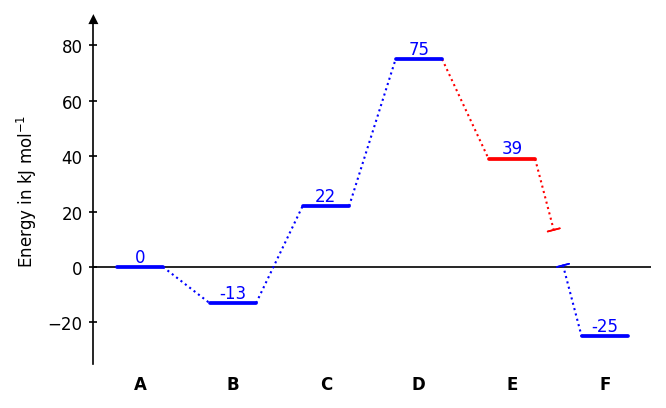

In [23]:
dia1 = EnergyDiagram()

dia1.draw_path(
    x_data=x_data_1,
    y_data=y_data_1,
    linetypes=[1,1,1,1,-1],
    color='blue',
    path_name="Pathway 1"
)

dia1.add_numbers_auto()

# Show lines dict
print(dia1.lines)

# Set color of plateau at x = 4 to red
plateau = dia1.lines["Pathway 1"].plateaus["4.0"]
plateau.set_color("red")

# Set color of connector between 3 and 4 to red
connector1 = dia1.lines["Pathway 1"].connections["3.5"]
connector1.set_color("red")

# # Set first half of connector between 4 and 5 to red
connector2 = dia1.lines["Pathway 1"].connections["4.5"].line_part_1
connector2s = dia1.lines["Pathway 1"].connections["4.5"].stopper_1
connector2.set_color("red")
connector2s.arrow_patch.set_color("red")

dia1.set_xlabels(["A", "B", "C", "D", "E", "F"])
dia1.ax.set_ylabel("Energy in kJ mol$^{-1}$", fontsize=8)
dia1.show()

MergedPlateau(plateau_left=<matplotlib.collections.LineCollection object at 0x00000168F1E79590>, plateau_right=<matplotlib.collections.LineCollection object at 0x00000168F1E796D0>, stopper_left=Text(1.9510825317547305, 0.015624999999999998, ''), stopper_right=Text(2.048917468245269, -0.015624999999999998, ''), whitespace=<matplotlib.patches.Rectangle object at 0x00000168F1E79810>)


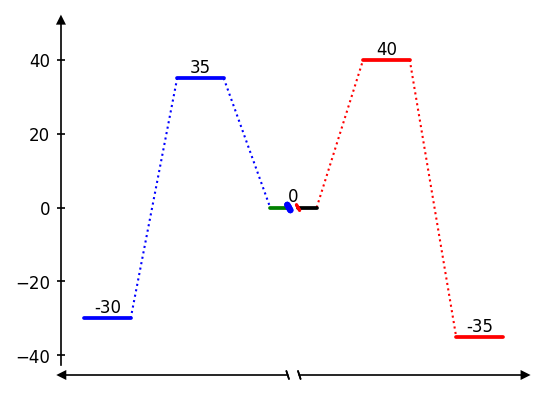

In [24]:
dia = EnergyDiagram(style="twosided", dpi=150)

dia.draw_path(
    [0,1,2], [-30,35,0], "blue",
    path_name="Blue path",
    linetypes=[1,1],
)



dia.draw_path(
    [2,3,4], [0, 40, -35], "red",
    path_name="Red path",
    linetypes=[1,1],
)

dia.merge_plateaus(
    2, "Blue path", "Red path",
)

# Get and print the MergedPlateau Object
mp = dia.lines["Red path"].plateaus["2.0"]
print(mp)

# Change colors and stopper sizes
mp.plateau_left.set_color("green")
mp.plateau_right.set_color("black")
mp.stopper_left.arrow_patch.set_lw(3)

dia.add_numbers_average(color="black")


dia.add_xaxis_break(2)

## Path labels

Path labels are accessed via the dia.lines["path_name"].labels attribute, which is a dictionary of the respective labels, keyed by the x position of the label as a string (e.g. "0.0", "1.0", etc.). The label objects are matplotlib Text objects, so all their properties can be modified directly.

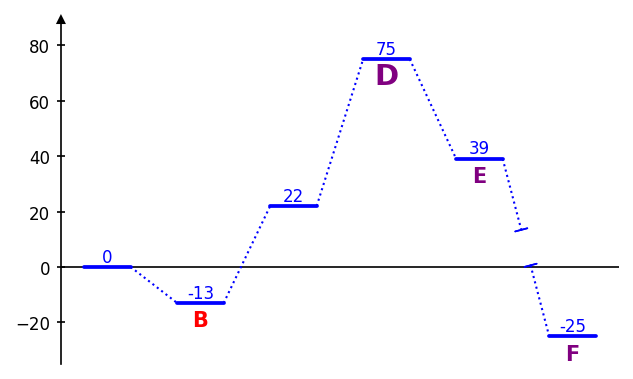

In [53]:
dia1 = EnergyDiagram()

dia1.draw_path(
    x_data=x_data_1,
    y_data=y_data_1,
    linetypes=[1,1,1,1,-1],
    color='blue',
    path_name="Pathway 1"
)

dia1.add_numbers_auto()

dia1.add_path_labels(
    "Pathway 1",
    [None, "B", None, "D", "E", "F"],
    fontsize=10,
    color="purple",
    weight="bold"
)

dia1.lines["Pathway 1"].labels["1.0"].set_color("red")    # Accessing the label at x = 1 and setting its color to red
dia1.lines["Pathway 1"].labels["3.0"].set_fontsize(14)   # Accessing the label at x = 3 

dia1.show()

## Number objects

{'Pathway 1': {'0.0': Text(0.0, 3.7499999999999996, '0'), '1.0': Text(1.0, -9.25, '-13'), '2.0': Text(2.0, 25.75, '22'), '3.0': Text(3.0, 78.75, '75'), '4.0': Text(4.0, 42.75, '39'), '5.0': Text(5.0, -21.25, '-25')}}


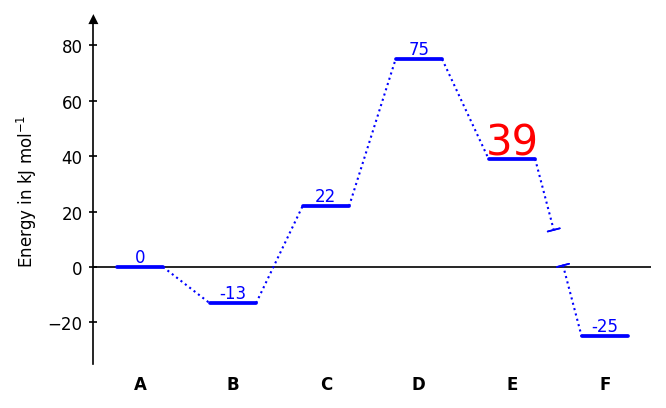

In [25]:
dia1 = EnergyDiagram()

dia1.draw_path(
    x_data=x_data_1,
    y_data=y_data_1,
    linetypes=[1,1,1,1,-1],
    color='blue',
    path_name="Pathway 1"
)

dia1.add_numbers_auto()

# Show numbers dict
print(dia1.numbers)

# Set color of number at x = 4 to red and shift
number_text = dia1.numbers["Pathway 1"]["4.0"]
number_text.set_color("red")
number_text.set_y(45)
number_text.set_fontsize(20)


dia1.set_xlabels(["A", "B", "C", "D", "E", "F"])
dia1.ax.set_ylabel("Energy in kJ mol$^{-1}$", fontsize=8)
dia1.show()

## Axes/Style objects

If labels are shown in the plot, they are not the standard label objects, but instead plain text objects accessible via ax_objects. With ax_objects, also the arrows and the axhline for style="open" are accessible.

StyleObjects(arrows={'y_arrow': Text(0, 0.97, '')}, axes={'x_axis': <matplotlib.lines.Line2D object at 0x00000168F3D5BD90>}, x_labels={'0.0': Text(0, -4.999999999999999, 'A'), '1.0': Text(1, -18.0, 'B'), '2.0': Text(2, 17.0, 'C'), '3.0': Text(3, 70.0, 'D'), '4.0': Text(4, 34.0, 'E'), '5.0': Text(5, -30.0, 'F')}, xaxis_breaks={}, yaxis_breaks={})


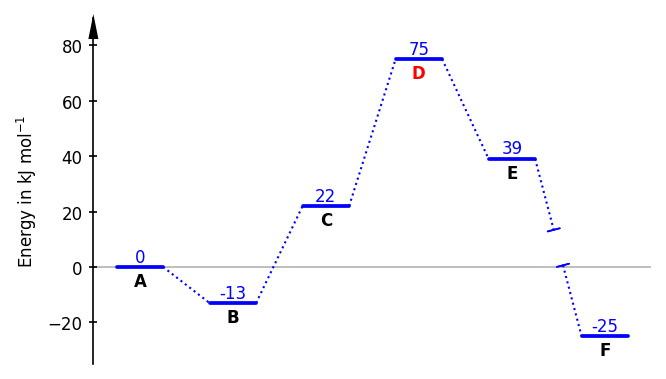

In [26]:
dia1 = EnergyDiagram()

dia1.draw_path(
    x_data=x_data_1,
    y_data=y_data_1,
    linetypes=[1,1,1,1,-1],
    color='blue',
    path_name="Pathway 1"
)

dia1.add_numbers_auto()
dia1.set_xlabels(["A", "B", "C", "D", "E", "F"], in_plot=True)

# Show axes objects
print(dia1.ax_objects)

# Make y_arrow longer
y_arrow = dia1.ax_objects.arrows["y_arrow"]
y_arrow.arrow_patch.set_mutation_aspect(2.5)

# Make line at x=0 less visible
zeroline = dia1.ax_objects.axes["x_axis"]
zeroline.set_alpha(0.3)

# Make label D red
label = dia1.ax_objects.x_labels["3.0"]
label.set_color("red")


dia1.ax.set_ylabel("Energy in kJ mol$^{-1}$", fontsize=8)
dia1.show()

## Difference bars

Difference bars are accessed via bars and ordered by their insertion rank.

[DifferenceBar(bar=Text(2.5, -13, ''), text=Text(2.525, 4.5, '$\\Delta E_{1}$: 35'), whisker_1=<matplotlib.lines.Line2D object at 0x00000168F251D090>, whisker_2=<matplotlib.lines.Line2D object at 0x00000168F251D1D0>), DifferenceBar(bar=Text(1.5, 22, ''), text=Text(1.475, 48.5, '$\\Delta E_{2}$: 53'), whisker_1=<matplotlib.lines.Line2D object at 0x00000168F251D6D0>, whisker_2=<matplotlib.lines.Line2D object at 0x00000168F251D810>)]


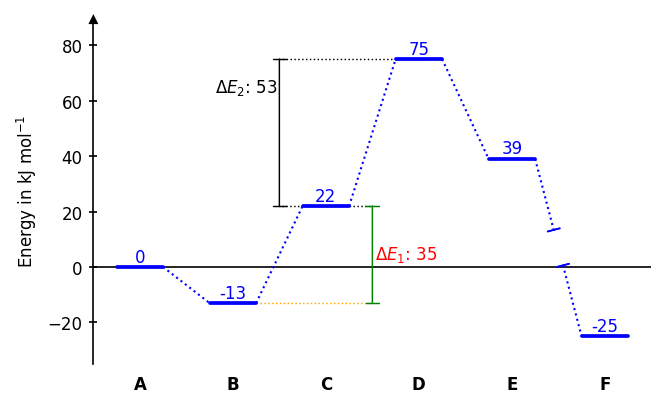

In [27]:
dia1 = EnergyDiagram()

dia1.draw_path(
    x_data=x_data_1,
    y_data=y_data_1,
    linetypes=[1,1,1,1,-1],
    color='blue',
    path_name="Pathway 1"
)

dia1.add_numbers_auto()
dia1.set_xlabels(["A", "B", "C", "D", "E", "F"])

# Bar Nr 0
dia1.draw_difference_bar(
    2.5, 
    [y_data_1[1], y_data_1[2]], 
    r"$\Delta E_{1}$: ", 
    x_whiskers=(1,2)
)

# Bar Nr 1
dia1.draw_difference_bar(
    1.5, 
    [y_data_1[2], y_data_1[3]], 
    r"$\Delta E_{2}$: ", 
    x_whiskers=(2,3),
    left_side=True
)

# Show bar object
print(dia1.bars)

# Change colors of the bar 0
bar_text = dia1.bars[0].text
bar_bar = dia1.bars[0].bar
bar_whis1 = dia1.bars[0].whisker_1
bar_text.set_color("red")
bar_bar.arrow_patch.set_color("green")
bar_whis1.set_color("orange")

# Change colors of the bar 1
bar_text = dia1.bars[1].text
bar_text.set_y(65)

dia1.ax.set_ylabel("Energy in kJ mol$^{-1}$", fontsize=8)
dia1.show()

## Images

Images can be accessed via images property and selected by their name and x-value in the case of image series.

In [28]:
# Get dummy images
import os
penguin = os.path.join("figures", "penguin.png")
penguin_TS = os.path.join("figures", "penguin_TS.png")
penguin_II = os.path.join("figures", "penguin_2.png")

ImageObject(image=<matplotlib.image.AxesImage object at 0x00000168F2298A50>, borders={'top': <matplotlib.lines.Line2D object at 0x00000168F2298B90>, 'bottom': <matplotlib.lines.Line2D object at 0x00000168F2298CD0>, 'left': <matplotlib.lines.Line2D object at 0x00000168F2298E10>, 'right': <matplotlib.lines.Line2D object at 0x00000168F2298F50>})
ImageObject(image=<matplotlib.image.AxesImage object at 0x00000168F2298190>, borders={'top': <matplotlib.lines.Line2D object at 0x00000168F22982D0>, 'bottom': <matplotlib.lines.Line2D object at 0x00000168F2298410>, 'left': <matplotlib.lines.Line2D object at 0x00000168F2298550>, 'right': <matplotlib.lines.Line2D object at 0x00000168F2298690>})


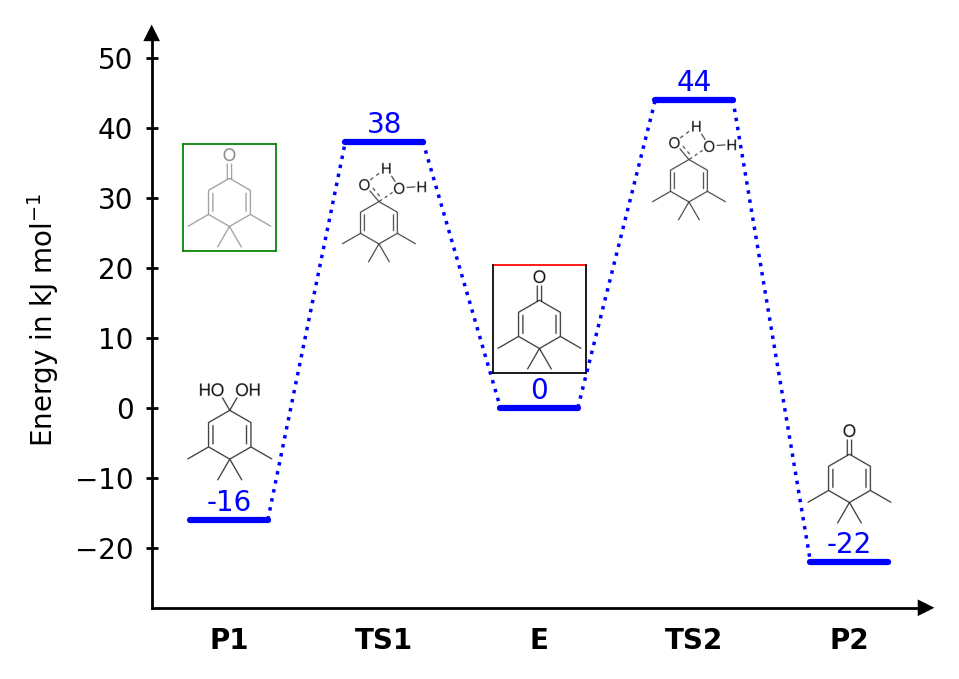

In [29]:
dia1 = EnergyDiagram(
    dpi=250,
    style="halfboxed"
)

dia1.draw_path(
    x_data=x_data_3,
    y_data=y_data_4,
    color='blue',
)

dia1.add_numbers_auto()
dia1.set_xlabels(["P1", "TS1", "E", "TS2", "P2"])
dia1.ax.set_ylabel("Energy in kJ mol$^{-1}$", fontsize=8)

dia1.add_image_series_in_plot(
    [penguin_II, penguin_TS, penguin, penguin_TS, penguin],
    framed=[False, False, True, False, False]         ,
    img_series_name="pinguin_series"          
)

dia1.add_image_in_plot(
    penguin,
    (0, 30),
    framed=True,
    frame_color="green",
    img_name="lone_pinguin"               
)

# Access lone image
lone_img = dia1.images["lone_pinguin"]
print(lone_img)

# Access image in series at x = 2
img_2 = dia1.images["pinguin_series"]["2.0"]
print(img_2)

# Set opacity of lone image to 0.5
lone_img.image.set_alpha(0.5)

# Set color of top line to red
img_2.borders["top"].set_color("red")



dia1.show()